# Notebook 5 — TensorFlow Custom Components

This notebook focuses on custom TensorFlow / Keras building blocks for regression.

## Topics covered

This notebook includes:

- custom loss function
- custom metric
- custom activation
- custom initializer
- custom regularizer
- custom kernel constraint
- baseline vs custom-model comparison
- summary tables and plots

## Dataset

The California Housing dataset is used for a compact regression workflow.  
The target is median house value, and the experiments compare a standard model with a model built from custom Keras components.


In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

plt.rcParams["figure.figsize"] = (8, 4)
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


## Dataset preparation

The California Housing dataset contains numerical features describing census blocks in California.  
The task is regression: predicting the median house value from the available features.


In [ ]:
housing = fetch_california_housing(as_frame=True)
X = housing.data.astype("float32")
y = housing.target.astype("float32")

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=SEED
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype("float32")
X_valid = scaler.transform(X_valid).astype("float32")
X_test = scaler.transform(X_test).astype("float32")

feature_names = list(housing.data.columns)

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)
print("Test :", X_test.shape)

pd.DataFrame(X_train[:5], columns=feature_names)


Train: (13209, 8)
Valid: (3303, 8)
Test : (4128, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,0.443410,-0.124495,0.520471,0.057586,-0.487101,0.051658,1.102818,-0.691555
1,0.003210,-1.077708,-0.170839,-0.048722,1.699027,-0.055159,-0.724940,0.854433
2,-0.521812,-0.203929,-0.061250,0.280896,-0.135350,-0.016972,-0.884283,0.864410
3,0.598503,0.431546,0.497560,0.109829,-0.634836,-0.041738,-0.607776,-0.078145
4,0.618135,-0.283364,0.455534,-0.226255,0.378205,-0.075323,1.337146,-0.960857


## Helper functions

The helper functions below keep the training and comparison workflow consistent across experiments.


In [ ]:
def compile_and_train(model, X_train, y_train, X_valid, y_valid, X_test, y_test,
                      epochs=25, learning_rate=1e-3, verbose=0):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=model.loss_fn,
        metrics=model.metrics_list
    )
    history = model.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        epochs=epochs,
        verbose=verbose
    )
    test_results = model.evaluate(X_test, y_test, verbose=0, return_dict=True)
    return history, test_results

def plot_history(history, title):
    hist = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    hist[["loss", "val_loss"]].plot(ax=axes[0], title=f"{title} - Loss")

    metric_cols = [c for c in hist.columns if ("mae" in c or "rmse" in c or "huber" in c)]
    if metric_cols:
        hist[metric_cols].plot(ax=axes[1], title=f"{title} - Metrics")

    axes[0].set_xlabel("Epoch")
    axes[1].set_xlabel("Epoch")
    plt.tight_layout()
    plt.show()

def summarize_run(name, history, test_results):
    hist = history.history
    out = {
        "experiment": name,
        "final_train_loss": float(hist["loss"][-1]),
        "final_val_loss": float(hist["val_loss"][-1]),
        "best_val_loss": float(np.min(hist["val_loss"])),
        "test_loss": float(test_results["loss"]),
        "epochs_ran": len(hist["loss"]),
    }
    for key, value in test_results.items():
        if key != "loss":
            out[f"test_{key}"] = float(value)
    return out

def compare_results(results, sort_col="test_loss", ascending=True):
    return pd.DataFrame(results).sort_values(sort_col, ascending=ascending).reset_index(drop=True)


## Baseline regression model

The baseline model uses standard Keras components and mean squared error for regression.


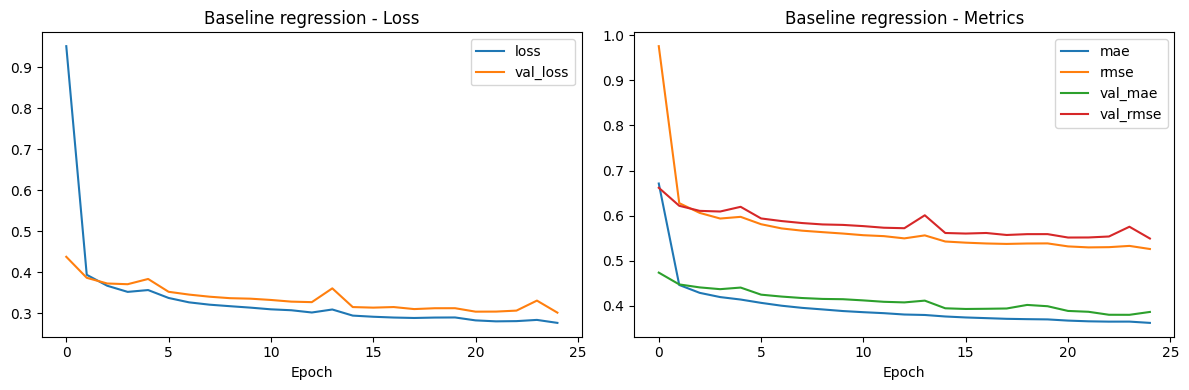

,experiment,final_train_loss,final_val_loss,best_val_loss,test_loss,epochs_ran,test_mae,test_rmse
0,baseline_model,0.276897,0.301863,0.301863,0.30096,25,0.381319,0.548598


In [ ]:
def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])
    model.loss_fn = keras.losses.MeanSquaredError()
    model.metrics_list = [
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.RootMeanSquaredError(name="rmse"),
    ]
    return model

baseline_model = build_baseline_model()
baseline_history, baseline_test_results = compile_and_train(
    baseline_model,
    X_train, y_train,
    X_valid, y_valid,
    X_test, y_test,
    epochs=25,
    verbose=0
)

plot_history(baseline_history, "Baseline regression")

baseline_results = [summarize_run("baseline_model", baseline_history, baseline_test_results)]
compare_results(baseline_results)


### Interpretation

The baseline model provides the reference point for the custom-component experiments.


## Custom loss function and custom metric

A Huber-style loss is less sensitive to large residuals than mean squared error.  
A matching custom metric is defined to track the same objective explicitly during training.


In [ ]:
class CustomHuberLoss(keras.losses.Loss):
    def __init__(self, delta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.delta = delta

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(tf.squeeze(y_pred, axis=-1), tf.float32)

        error = y_true - y_pred
        abs_error = tf.abs(error)
        quadratic = tf.minimum(abs_error, self.delta)
        linear = abs_error - quadratic

        return tf.reduce_mean(0.5 * tf.square(quadratic) + self.delta * linear)

    def get_config(self):
        config = super().get_config()
        config.update({"delta": self.delta})
        return config


class CustomHuberMetric(keras.metrics.Metric):
    def __init__(self, delta=1.0, name="custom_huber", **kwargs):
        super().__init__(name=name, **kwargs)
        self.delta = delta
        self.total = self.add_weight(name="total", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(tf.squeeze(y_pred, axis=-1), tf.float32)

        error = y_true - y_pred
        abs_error = tf.abs(error)
        quadratic = tf.minimum(abs_error, self.delta)
        linear = abs_error - quadratic
        values = 0.5 * tf.square(quadratic) + self.delta * linear

        if sample_weight is not None:
            sample_weight = tf.cast(sample_weight, tf.float32)
            values = values * sample_weight

        self.total.assign_add(tf.reduce_sum(values))
        self.count.assign_add(tf.cast(tf.size(values), tf.float32))

    def result(self):
        return tf.math.divide_no_nan(self.total, self.count)

    def reset_state(self):
        self.total.assign(0.0)
        self.count.assign(0.0)

    def get_config(self):
        config = super().get_config()
        config.update({"delta": self.delta})
        return config


## Custom activation, initializer, regularizer, and constraint

The custom model below combines several user-defined components:

- a custom activation function,
- a custom Glorot-style initializer,
- a custom L1 regularizer,
- a non-negative kernel constraint.


In [ ]:
def custom_activation(x):
    return 1.2 * tf.nn.softplus(x) - 0.6


class CustomGlorotInitializer(keras.initializers.Initializer):
    def __call__(self, shape, dtype=None):
        fan_in = tf.cast(shape[0], tf.float32)
        fan_out = tf.cast(shape[1], tf.float32)
        stddev = tf.sqrt(2.0 / (fan_in + fan_out))
        return tf.random.normal(shape, stddev=stddev, dtype=dtype or tf.float32)


class CustomL1Regularizer(keras.regularizers.Regularizer):
    def __init__(self, factor=1e-5):
        self.factor = factor

    def __call__(self, x):
        return self.factor * tf.reduce_sum(tf.abs(x))

    def get_config(self):
        return {"factor": self.factor}


class NonNegativeConstraint(keras.constraints.Constraint):
    def __call__(self, w):
        return tf.nn.relu(w)


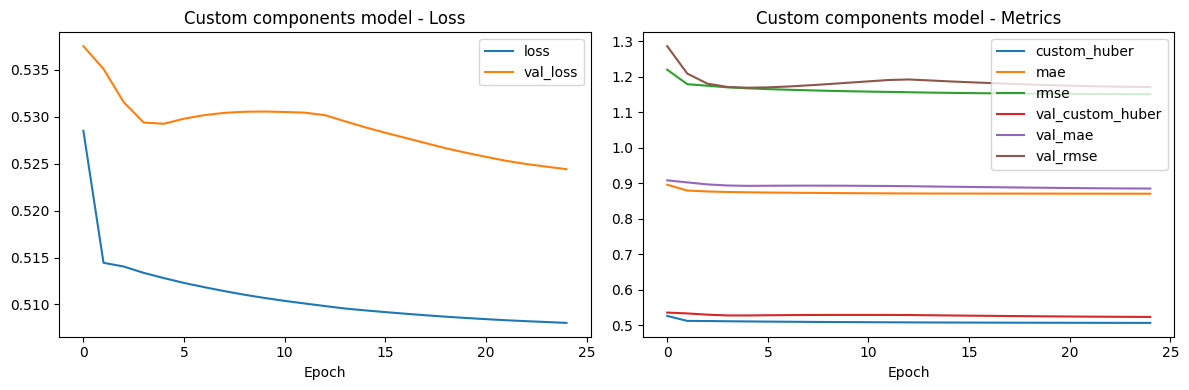

In [ ]:
def build_custom_components_model():
    initializer = CustomGlorotInitializer()
    regularizer = CustomL1Regularizer(1e-5)
    constraint = NonNegativeConstraint()

    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(
            64,
            activation=custom_activation,
            kernel_initializer=initializer,
            kernel_regularizer=regularizer,
            kernel_constraint=constraint,
        ),
        layers.Dense(
            32,
            activation=custom_activation,
            kernel_initializer=initializer,
            kernel_regularizer=regularizer,
            kernel_constraint=constraint,
        ),
        layers.Dense(1)
    ])
    model.loss_fn = CustomHuberLoss(delta=1.0)
    model.metrics_list = [
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.RootMeanSquaredError(name="rmse"),
        CustomHuberMetric(delta=1.0),
    ]
    return model

custom_model = build_custom_components_model()
custom_history, custom_test_results = compile_and_train(
    custom_model,
    X_train, y_train,
    X_valid, y_valid,
    X_test, y_test,
    epochs=25,
    verbose=0
)

plot_history(custom_history, "Custom components model")


### Interpretation

The custom model combines user-defined Keras components inside a single trainable network.  
This makes it possible to customize the objective, metrics, activation behavior, initialization, regularization, and weight constraints.


## Side-by-side comparison


In [ ]:
results_df = compare_results([
    summarize_run("baseline_model", baseline_history, baseline_test_results),
    summarize_run("custom_components_model", custom_history, custom_test_results),
], sort_col="test_loss", ascending=True)

results_df


,experiment,final_train_loss,final_val_loss,best_val_loss,test_loss,epochs_ran,test_mae,test_rmse,test_custom_huber
0,baseline_model,0.276897,0.301863,0.301863,0.300960,25,0.381319,0.548598,NaN
1,custom_components_model,0.508037,0.524406,0.524406,0.502199,25,0.860896,1.135325,0.501588


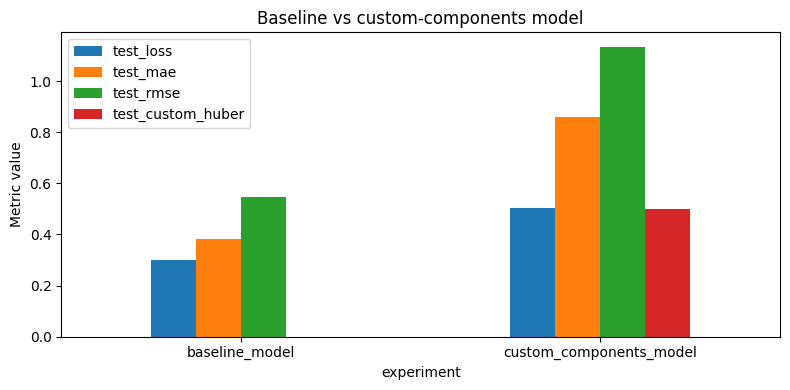

In [ ]:
plot_cols = [c for c in ["test_loss", "test_mae", "test_rmse", "test_custom_huber"] if c in results_df.columns]

ax = results_df.set_index("experiment")[plot_cols].plot(kind="bar", rot=0)
ax.set_title("Baseline vs custom-components model")
ax.set_ylabel("Metric value")
plt.tight_layout()
plt.show()


## Key conclusions

This notebook demonstrates a complete custom-component workflow in Keras:
- custom loss
- custom metric
- custom activation
- custom initializer
- custom regularizer
- custom kernel constraint

These components integrate directly into the standard Keras training pipeline and provide finer control over model behavior.
